**Lab 5: FIR Filtering 2**

The goal of this lab is to study the response of FIR filters to inputs such as complex exponentials and sinusoids. In the experiments of this lab, you will use `np.convolve()` to implement filters and `freqz()` to obtain the filter’s frequency response. As a result, you should learn how to characterize a filter by knowing how it reacts to different frequency components in the input.
This lab also introduces two practical filters: bandpass filters and nulling filters.
Bandpass filters can be used to detect and extract information from complex signals,
e.g., tones in a touch-tone telephone dialer. Nulling filters can be used to remove
sinusoidal interference, e.g., jamming signals in a radar.

In [1]:
import os
import numpy as np
import librosa
import IPython.display as ipd
from scipy import signal
import matplotlib.pyplot as plt

from util import load_audio, plot_signals, plot_spectrogram, plot_mean_spectrogram

1.1. First, let's replicate what we did until now. Copy the functions synthesize and envelope and obtain the synthesis from the last lab.

In [2]:
def averaging_filter(x, N):
    b = np.ones(N) / N
    return np.convolve(x, b, mode='same')

def envelope(x, N):
    full_wave = np.abs(x)
    return averaging_filter(full_wave, N)

def synthesize(f0, phi, Ak, t):
    y = np.zeros_like(t, dtype=float)
    for k in range(1, len(Ak) + 1):
        y += Ak[k-1] * np.cos(2*np.pi*k*f0*t + k*phi - (k-1)*np.pi/2)
    return y

# Load reference audio (ajusta filepath si hace falta)
filepath = "audio/136954__stomachache__gsharp1.wav"
ref, fs = load_audio(filepath)

# Parámetros de la síntesis (usar los valores del laboratorio anterior)
f0 = 416.037
phi = ((0.317277 - 0.31608) / 0.0024266) * 2 * np.pi
t = np.arange(len(ref)) / fs
weights = [1, 0.0264, 0.0143, 0.032, 0.005, 0.0005, 0.00095]

# Generar síntesis y envolvente; aplicar envolvente a la síntesis
s = synthesize(f0, phi, weights, t)
env = envelope(ref, 150)   # N puede ajustarse
synthesized = s * env

1.2 Plot both reference and synthesised signal.

In [3]:
# Write your code here# ...existing code...
# Plot both reference and synthesized signals (time domain)
# Show a short segment for clarity (e.g., first 2 seconds) and play the synthesized audio.
duration_sec = 2.0
n_samples = int(min(len(ref), len(synthesized), duration_sec * fs))

plot_signals([ref[:n_samples], synthesized[:n_samples]], fs, 
             name=['Reference (first {}s)'.format(duration_sec), 'Synthesized (first {}s)'.format(duration_sec)])

# Reproduce full synthesized sound (optional)
ipd.display(ipd.Audio(synthesized, rate=fs))
# ...existing code...

---

In [5]:
from util import plot_frequency_response

ww = np.arange(-np.pi, np.pi, np.pi/500)
_, HH = signal.freqz([1/4]*4, 1, ww)

plot_frequency_response(ww, HH)


def add_interference(x, fs):
  t = np.linspace(0, len(x)*1/float(fs), len(x))
  y = x + (np.amax(x)/10)*np.sin(2*np.pi*1000*t)
  return y


**2. Averaging filter**

Now let's analyze the frequency response of the average filter used in the envelope function. The Scipy Python module has a function called *freqz()* for computing the frequency
response of a discrete-time LTI system. The following Python statements show how to
use freqz to compute and plot both the magnitude (absolute value) and the phase of
the frequency response of a four-point averaging system as a function of ω in the range − π ≤ ω ≤ π :

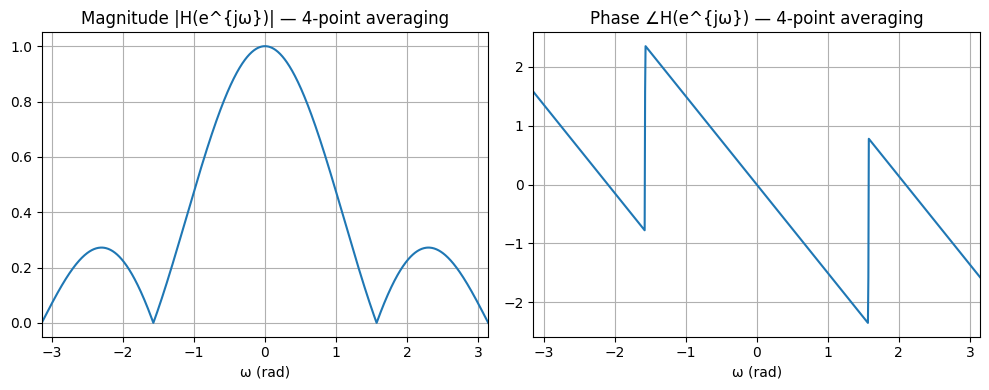

In [20]:
# Example: 4-point averaging frequency response (ω from -π to π)
ww = np.linspace(-np.pi, np.pi, 1001)
b4 = np.ones(4) / 4
_, H4 = signal.freqz(b4, 1, worN=ww, whole=False)

# Plot magnitude and phase using matplotlib (no try/except)
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(ww, np.abs(H4))
plt.title('Magnitude |H(e^{jω})| — 4-point averaging')
plt.xlabel('ω (rad)')
plt.xlim([-np.pi, np.pi])
plt.grid(True)
plt.subplot(1,2,2)
plt.plot(ww, np.unwrap(np.angle(H4)))
plt.title('Phase ∠H(e^{jω}) — 4-point averaging')
plt.xlabel('ω (rad)')
plt.xlim([-np.pi, np.pi])
plt.grid(True)
plt.tight_layout()


For FIR filters, the second argument of `freqz(-, 1,- )` must always be equal to 1. The frequency vector ww should cover an interval of length 2π for ω , and its spacing must be fine enough to give a smooth curve for H(ejω) . Note: we will always use capital H for the frequency response.

2.1 Use the `freqz` and `plot_frequency_response` functions to plot the frequency response of the averaging filter of your envelope function.



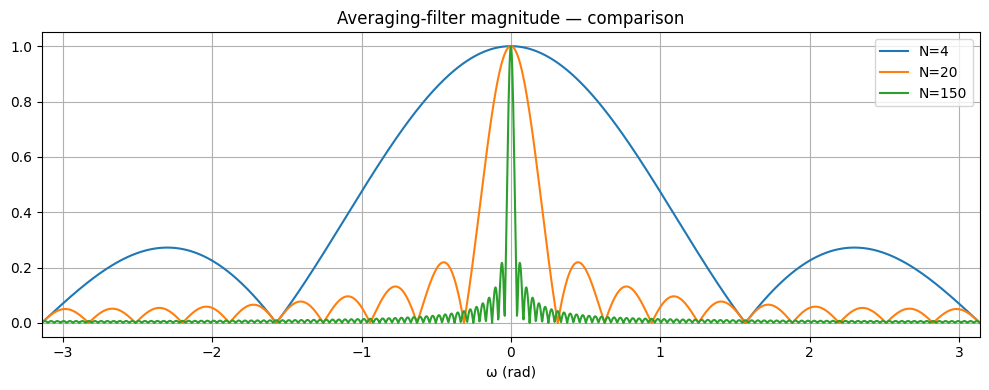

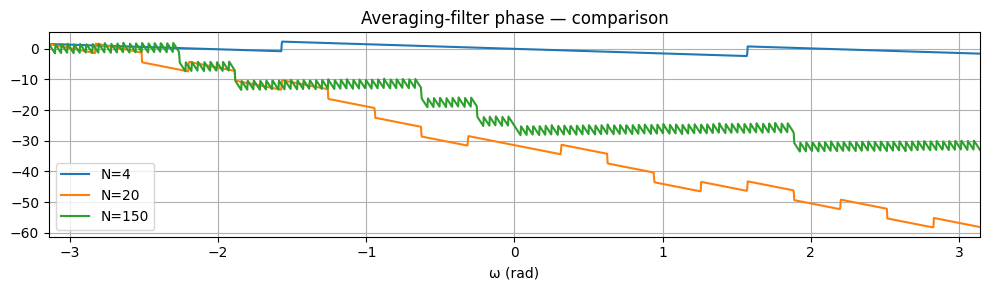

In [17]:
# Compute and compare averaging-filter frequency responses for different N
Ns = [4, 20, 150]  # include the envelope N (150) used above
ww = np.linspace(-np.pi, np.pi, 2001)
# Plot magnitude responses overlaid for comparison
plt.figure(figsize=(10,4))
for N in Ns:
    b = np.ones(N) / N
    _, H = signal.freqz(b, 1, worN=ww, whole=False)
    plt.plot(ww, np.abs(H), label=f'N={N}')
plt.title('Averaging-filter magnitude — comparison')
plt.xlabel('ω (rad)')
plt.xlim([-np.pi, np.pi])
plt.legend()
plt.grid(True)
plt.tight_layout()

# Optional: separate phase figure
plt.figure(figsize=(10,3))
for N in Ns:
    b = np.ones(N) / N
    _, H = signal.freqz(b, 1, worN=ww, whole=False)
    plt.plot(ww, np.unwrap(np.angle(H)), label=f'N={N}')
plt.title('Averaging-filter phase — comparison')
plt.xlabel('ω (rad)')
plt.xlim([-np.pi, np.pi])
plt.legend()
plt.grid(True)
plt.tight_layout()

# Observations: as N increases the main lobe becomes narrower and the zeros (nulls) get closer together; the filter behaves more like a lowpass smoother.


2.2 Looking at the frequency responses, what are the main differences between your filter and the four-point averaging filter. What happens when the value N is increased?

Based on the frequency response plots, the main difference is in selectivity and delay.

The four-point (N=4) filter is a weak low-pass filter, it attenuates only very high frequencies. The N=150 filter is a very strong, selective low-pass filter that aggressively removes almost all frequency content that isn't DC (zero frequency). The second major difference is that the N=150 filter has a much steeper phase slope, which corresponds to a significantly larger time delay compared to the N=4 filter.

In general, as the value of N is increased, the filter becomes a better low-pass filter and acts as a stronger smoother. However,this increments the tiem delay. The number of nulls (zeros) in the frequency response also increases, packing closer together.

---

**3. Nulling Filters for Rejection**

Nulling filters are filters that completely eliminate some frequency components. If the frequency is $\omega=0$ or $\omega=\pi$ then a two-point FIR filter will do the nulling. The simplest possible general nulling filter can have as few as three coefficients. If $\omega_n$ is the desired nulling frequency, then the following length-3 FIR filter

$$
y[n] = x[n] - 2\cos(\omega_n)x[n-1] + x[n-2] 
$$

will have a zero in its frequency response at $\omega=\omega_n$. For example, a filter designed to completely eliminate signals of the form $e^{j0.5\pi}$ would have the following coefficients because we would pick the desired nulling frequency to be $\omega_n = 0.5\pi$

$$
b_0 = 1, \quad b1=-2cos(\omega_n)=0, \quad b_2=1
$$

3.1 Use the following function to add an interference in your reference signal. Name the corrupted signal as `x_interf`.

In [ ]:
def add_interference(x, fs):
  # Write your code here

Found 'x_ref' and 'fs_ref' from your environment.
An error occurred: add_interference() got an unexpected keyword argument 'wn'
Please ensure 'x_ref' and 'fs_ref' are correctly defined before this step.


In [ ]:
# Write your code here

3.2 Plot both the reference signal and the corrupted signal and listen to the latter one. 

In [ ]:
# Write your code here

3.3 Compare the spectrograms of the reference signal and the interference signal. 

In [ ]:
# Write your code here

3.4. Create a function `remove_interference(x, fs)` that applies a nulling filter devised to remove the interference at 1000 Hz. 

Note: remember that a frequency can be converted to the normalized radian frequncy by: $\omega_n = 2\pi f_n/f_s$

In [ ]:
def remove_interference(x, fs):
  """Applies nulling filter to remove an interference at 1000 Hz

  Parameters
  ----------
  x : np.array
      The input signal in the form of a numpy array
  fs : int or float
      Frequency rate in Hz

  Returns
  -------
  y : np.array
      The output of the filter

  """
  # Write your code here

3.5 Use the `remove_interference` funcion to clean the corrupted signal,  `x_interf`. Call the output as `x_clean`. Compare the spectrograms of both signals. Explain the result.

In [ ]:
# Write your code here